 Exploratory Data Analysis

In [104]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

In [105]:
# Load data
df_complete = pd.read_csv('../compact.csv')

# Number of countries
print("There are ", len(df_complete['country'].unique()), " distinct countries in the dataset before preprocessing")

There are  262  distinct countries in the dataset before preprocessing


After reviewing the data documentation provided by the data provider, we notice that some important variables — e.g. testing data — stop being recorded partway through the time period. Therefore, we subset the dataset to only retain dates where all variables of interest are consistently recorded.

In [106]:
# Columns that are completely NA
cols_NA = df_complete.columns[df_complete.isna().all()].tolist()
print(cols_NA)

df = df_complete.drop(columns=cols_NA)

# Find the last valid (non-NA) index for each column
last_valid = df.apply(lambda col: col.last_valid_index())
cutoff_date = df.loc[last_valid.values, 'date'].min()

print("Cutoff date:", cutoff_date)

# Subset dataset up to that cutoff_date
df = df[df['date'] <= cutoff_date]

['human_development_index']
Cutoff date: 2022-05-19


After the EDA on socioeconomic and demographic covariates (included in a separate notebook), the set of covariates narrows down to the following, and we filter out the countries not reporting these variables.

In [107]:
cols_to_drop = ['handwashing_facilities', 'extreme_poverty']
df = df.drop(columns=cols_to_drop)

cols_of_interest_social = ['population_density', 'gdp_per_capita', 'hospital_beds_per_thousand', 'life_expectancy']

df = (
    df.groupby('country', group_keys=False)
    .filter(lambda x: x[cols_of_interest_social].notna().any(axis=0).all())
)

df[cols_of_interest_social] = (
    df.groupby('country', group_keys=False)[cols_of_interest_social]
    .transform(lambda x: x.ffill().bfill())
)

df['date'] = pd.to_datetime(df['date'])

In [108]:
# Also drop the non-countries as suggested in another EDA notebook
non_countries = ['Africa', 'Asia', 'Asia excl. China', 'Europe', 'European Union (27)', 'High-income countries', 'Low-income countries', 'Lower-middle-income countries', 'North America', 'Oceania', 'South America', 'Summer Olympics 2020', 'Upper-middle-income countries', 'Winter Olympics 2022', 'World', 'World excl. China', 'World excl. China and South Korea', 'World excl. China, South Korea, Japan and Singapore']
df = df[~df['country'].isin(non_countries)]

In [109]:
# Current number of countries
print("There are ", len(df['country'].unique()), " distinct countries in the dataset after first round of subseting preprocessing")

There are  142  distinct countries in the dataset after first round of subseting preprocessing


In [111]:
# Basic info
print(df.info(verbose=True, show_counts=True))

<class 'pandas.DataFrame'>
Index: 123513 entries, 0 to 569230
Data columns (total 58 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   country                                     123513 non-null  str           
 1   date                                        123513 non-null  datetime64[us]
 2   total_cases                                 123114 non-null  float64       
 3   new_cases                                   123100 non-null  float64       
 4   new_cases_smoothed                          122396 non-null  float64       
 5   total_cases_per_million                     123114 non-null  float64       
 6   new_cases_per_million                       123100 non-null  float64       
 7   new_cases_smoothed_per_million              122396 non-null  float64       
 8   total_deaths                                123114 non-null  float64       
 9   new_death

The data provider has already grouped the variables into categories i.e. *Confirmed cases*, *Confirmed deaths*, *Excess mortality*, *Hospital & ICU*, *Policy responses*, *Tests & positivity*, *Vaccinations*, *Others (socialeconomics & demographical covariates)*. We now look into variables by category.

For *confirmed cases* and *confirmed deaths*, the variables are various variants of the number of reported cases and deaths after scaling or smoothing. We first get a sense of the data distribution by plotting the trend of the raw data.

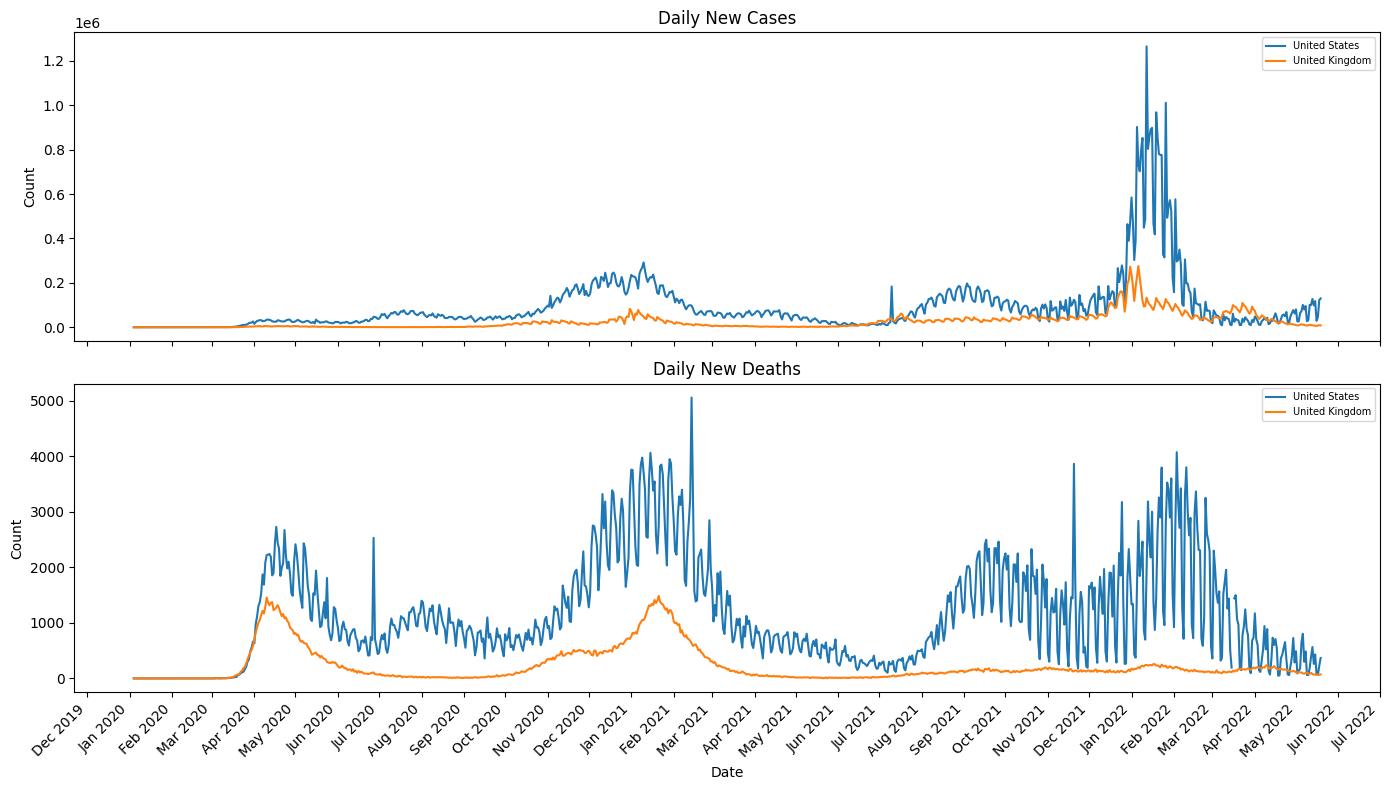

In [112]:
# Confirmed cases and confirmed death for selected countries
countries = ['United States', 'United Kingdom']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for location in countries:
    subset = df[df['country'] == location]
    axes[0].plot(subset['date'], subset['new_cases'], label=location)
    axes[1].plot(subset['date'], subset['new_deaths'], label=location)

axes[0].set_title('Daily New Cases')
axes[1].set_title('Daily New Deaths')

for ax in axes:
    ax.legend(fontsize=7)
    ax.set_ylabel('Count')

axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

On one hand, we observe abnormal spikes in the raw data, which is an intrinsic property of daily reported figures due to delayed or incorrect reporting. To address this, we focus on variants that apply 7-day smoothing — taking the average over a 7-day window — to reduce such spikes.


We also observe large differences in scale across countries, suggesting the need to account for population size. Therefore, we choose the variant that normalizes the data to counts per million people.

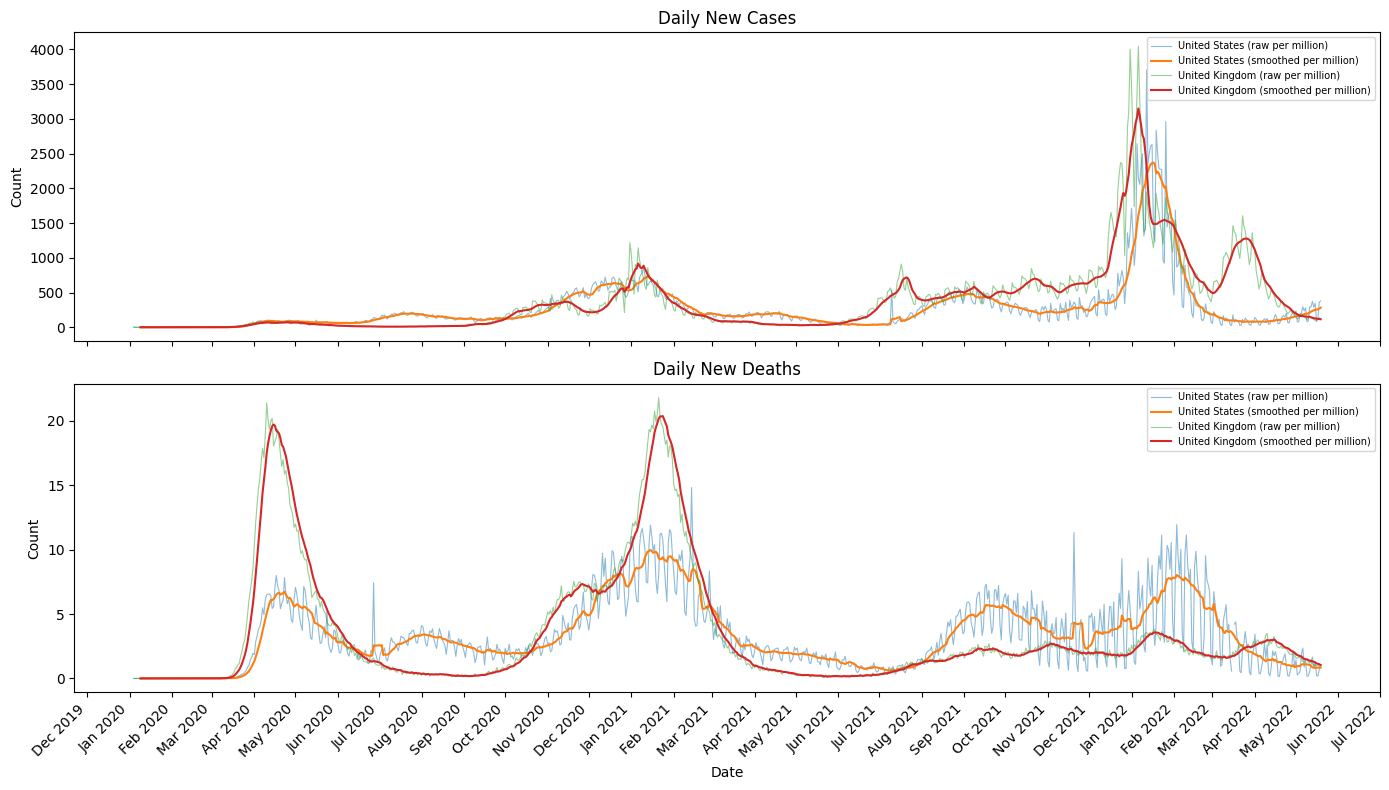

In [113]:
# Justify 7-day smoothing
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for location in countries:
    subset = df[df['country'] == location]
    
    # Raw data per million
    axes[0].plot(subset['date'], subset['new_cases_per_million'], alpha=0.5, linewidth=0.8, label=f'{location} (raw per million)')
    axes[1].plot(subset['date'], subset['new_deaths_per_million'], alpha=0.5, linewidth=0.8, label=f'{location} (raw per million)')
    
    # Smoothed per million
    axes[0].plot(subset['date'], subset['new_cases_smoothed_per_million'], linewidth=1.5, label=f'{location} (smoothed per million)')
    axes[1].plot(subset['date'], subset['new_deaths_smoothed_per_million'], linewidth=1.5, label=f'{location} (smoothed per million)')

axes[0].set_title('Daily New Cases')
axes[1].set_title('Daily New Deaths')

for ax in axes:
    ax.legend(fontsize=7)
    ax.set_ylabel('Count')

axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

As discussed in a note in the data documentation, due to varying protocols and challenges in the attribution of the cause of death, the number of confirmed deaths may not accurately represent the true number of deaths caused by COVID-19. We refer to the idea in the paper (Karlinsky & Kobak, 2021) to correct the number of reported deaths using excess mortality available.

In [114]:
# Compute undercount ratio per location
undercount = (
    df.groupby('country')
    .apply(lambda x: x['excess_mortality_cumulative_per_million'].max() / 
                     x['new_deaths_smoothed_per_million'].sum())
    .reset_index()
    .rename(columns={0: 'undercount_ratio'})
)

df = df.merge(undercount, on='country')
df['new_deaths_smoothed_per_million_adjusted'] = df['new_deaths_smoothed_per_million'] * df['undercount_ratio']

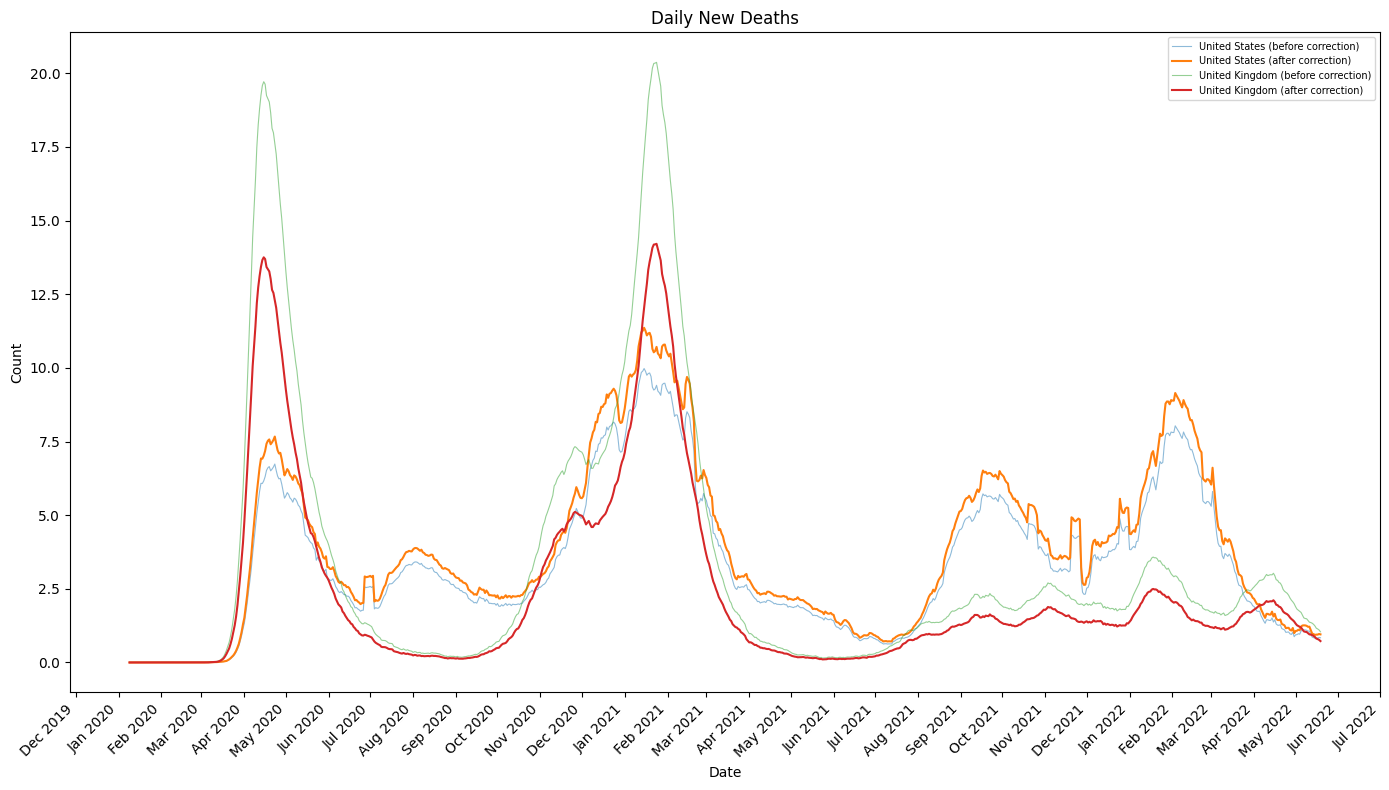

In [115]:
# Comparison after correction
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

for location in countries:
    subset = df[df['country'] == location]
    ax.plot(subset['date'], subset['new_deaths_smoothed_per_million'], alpha=0.5, linewidth=0.8, label=f'{location} (before correction)')
    ax.plot(subset['date'], subset['new_deaths_smoothed_per_million_adjusted'], linewidth=1.5, label=f'{location} (after correction)')

ax.set_title('Daily New Deaths')
ax.legend(fontsize=7)
ax.set_ylabel('Count')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

We can see that the count for the UK is slightly downscaled while that is slightly upscaled for the USA, which is consistent with the result in the paper (Karlinsky & Kobak, 2021) where the estimated undercount ratio for the UK is 0.9 while that for the USA is 1.1.

For similar reasons, for other categories, we also choose to focus on variables that are properly smoothed and normalized. We complete preliminary variable selection and end up with the following variables of interest.

In [116]:
cols_of_interest_time = ['new_cases_smoothed_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality_cumulative_per_million',
                    'stringency_index',
                    "new_tests_smoothed_per_thousand", "tests_per_case",
                    'new_people_vaccinated_smoothed_per_hundred']

We now look into the NAs and impute the missing data

In [117]:
na_portion = (
    df.groupby('country')[cols_of_interest_time]
    .apply(lambda x: x.isna().mean())
    .round(2)
)

# Only show countries with at least one NA
na_portion[na_portion.gt(0).any(axis=1)]

,new_cases_smoothed_per_million,new_deaths_smoothed_per_million,excess_mortality_cumulative_per_million,stringency_index,new_tests_smoothed_per_thousand,tests_per_case,new_people_vaccinated_smoothed_per_hundred
country,,,,,,,
Afghanistan,0.01,0.01,1.00,0.0,0.88,0.88,0.48
Albania,0.01,0.01,0.97,0.0,0.07,0.08,0.43
Algeria,0.01,0.01,0.97,0.0,1.00,1.00,0.45
Antigua and Barbuda,0.01,0.01,0.97,1.0,0.67,0.68,0.47
Argentina,0.01,0.01,0.97,0.0,0.01,0.07,0.42
...,...,...,...,...,...,...,...
United States,0.01,0.01,0.86,0.0,0.08,0.08,0.40
Uruguay,0.01,0.01,0.97,0.0,0.14,0.13,0.49
Uzbekistan,0.01,0.01,0.97,0.0,1.00,1.00,0.52


We can see that for `new_cases_smoothed_per_million` and `new_deaths_smoothed_per_million`, since the NAs account for only a small portion and they are time-dependent data recorded on a daily basis, it is safe to assume that values do not change much from day to day, and we use linear interpolation to impute the NAs.

In [118]:
cols_to_interpolate = ['new_cases_smoothed_per_million', 'new_deaths_smoothed_per_million']

df[cols_to_interpolate] = (
    df.groupby('country')[cols_to_interpolate]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

For `excess_mortality_cumulative_per_million`, we look into the time period of reporting and find that the NAs are due to the fact that it is reported on a weekly rather than a daily basis, leaving the remaining days within each week as missing, which means it is also valid to apply linear interpolation to impute the NAs.

In [119]:
us = df[df['country'] == 'United States']
us[us['excess_mortality_cumulative_per_million'].notna()][['date', 'excess_mortality_cumulative_per_million']]

,date,excess_mortality_cumulative_per_million
119167,2020-01-05,-5.700086
119174,2020-01-12,-13.174288
119181,2020-01-19,-21.369457
119188,2020-01-26,-26.844511
119195,2020-02-02,-31.324753
...,...,...
120000,2022-04-17,3314.198000
120007,2022-04-24,3312.486600
120014,2022-05-01,3315.106700
120021,2022-05-08,3318.349600


In [120]:
cols_to_interpolate = ['excess_mortality_cumulative_per_million']

df[cols_to_interpolate] = (
    df.groupby('country')[cols_to_interpolate]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

For `stringency_index`, we verify that countries either have a complete record or have only NAs. We simply exclude countries that do not report `stringency_index`.

In [121]:
na_portion = (
    df.groupby('country')['stringency_index']
    .apply(lambda x: x.isna().mean())
    .round(2)
)

# Check if all values are either 0 or 1
print(na_portion[~na_portion.isin([0, 1])])

Series([], Name: stringency_index, dtype: float64)


In [122]:
df = df[df['country'].isin(na_portion[na_portion < 1].index)]

In [123]:
# Current number of countries
print("There are ", len(df['country'].unique()), " distinct countries in the dataset after second round of subseting preprocessing")

There are  133  distinct countries in the dataset after second round of subseting preprocessing


For `new_people_vaccinated_smoothed_per_hundred`, we find that most NAs occur in the first few months, likely due to the fact that vaccines had not yet been available, so it is valid to replace those NAs with 0 and use linear interpolation to impute the remaining NAs.

In [124]:
def check_pre_vaccination_nas(x):
    first_valid = x.first_valid_index()
    if first_valid is None:
        pre_nas = x.isna().sum()
        post_nas = 0
    else:
        pre_nas = x.loc[:first_valid].isna().sum()
        post_nas = x.loc[first_valid:].isna().sum()
    total = pre_nas + post_nas
    pct_pre = pre_nas / total if total > 0 else 0
    return pd.Series({
        'pre_first_valid_na': pre_nas,
        'post_first_valid_na': post_nas,
        'pct_pre': round(pct_pre, 2)
    })

result = (
    df.groupby('country')['new_people_vaccinated_smoothed_per_hundred']
    .apply(check_pre_vaccination_nas)
)
result_pivot = result.unstack(level=1)
result_pivot[result_pivot['pct_pre'] < 1].sort_values('pct_pre')

,pre_first_valid_na,post_first_valid_na,pct_pre
country,,,
Bosnia and Herzegovina,408.0,110.0,0.79


Only country Bosnia and Herzegovina has remaining NAs

In [125]:
def fill_vaccination(x):
    first_valid = x.first_valid_index()
    if first_valid is None:
        return x.fillna(0)
    x.loc[:first_valid] = x.loc[:first_valid].fillna(0)
    return x.interpolate(method='linear', limit_direction='forward')

df['new_people_vaccinated_smoothed_per_hundred'] = (
    df.groupby('country')['new_people_vaccinated_smoothed_per_hundred']
    .transform(fill_vaccination)
)

For `new_tests_smoothed_per_thousand` and `tests_per_case`, we find that while some countries do not report testing data at all, most of the remaining countries are only missing data in the first few months, likely because systematic testing infrastructure was not yet in place. Since testing data provides significant insights into the latent process, we exclude countries that do not report any testing data and impute the early-stage missing values with 0. For the remaining few countries with a large proportion of NAs, we exclude them as well, as imputing data when too many values are missing is not justifiable.

In [126]:
valid_countries = (
    df.groupby('country')[['new_tests_smoothed_per_thousand', 'tests_per_case']]
    .apply(lambda x: x.notna().any(axis=0).all())
)

df = df[df['country'].isin(valid_countries[valid_countries].index)]

In [127]:
def impute_testing(x):
    first_valid = x.first_valid_index()
    if first_valid is None:
        return x.fillna(0)
    x.loc[:first_valid] = x.loc[:first_valid].fillna(0)
    return x

for col in ['new_tests_smoothed_per_thousand', 'tests_per_case']:
    df[col] = df.groupby('country')[col].transform(impute_testing)

In [128]:
# We exclude countries still having large portion of NAs
df = df[~df['country'].isin(na_portion[na_portion > 0.1].dropna(how='all').index.tolist())]

# Impute the rest of NAs via linear interpolation
cols_to_interpolate = ['new_tests_smoothed_per_thousand', 'tests_per_case']

df[cols_to_interpolate] = (
    df.groupby('country')[cols_to_interpolate]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [129]:
# Current number of countries
print("There are ", len(df['country'].unique()), " distinct countries in the dataset after third round of subseting preprocessing")

There are  121  distinct countries in the dataset after third round of subseting preprocessing


We generate plots to examine how the trends of these variables relate to that of the reported infection cases.

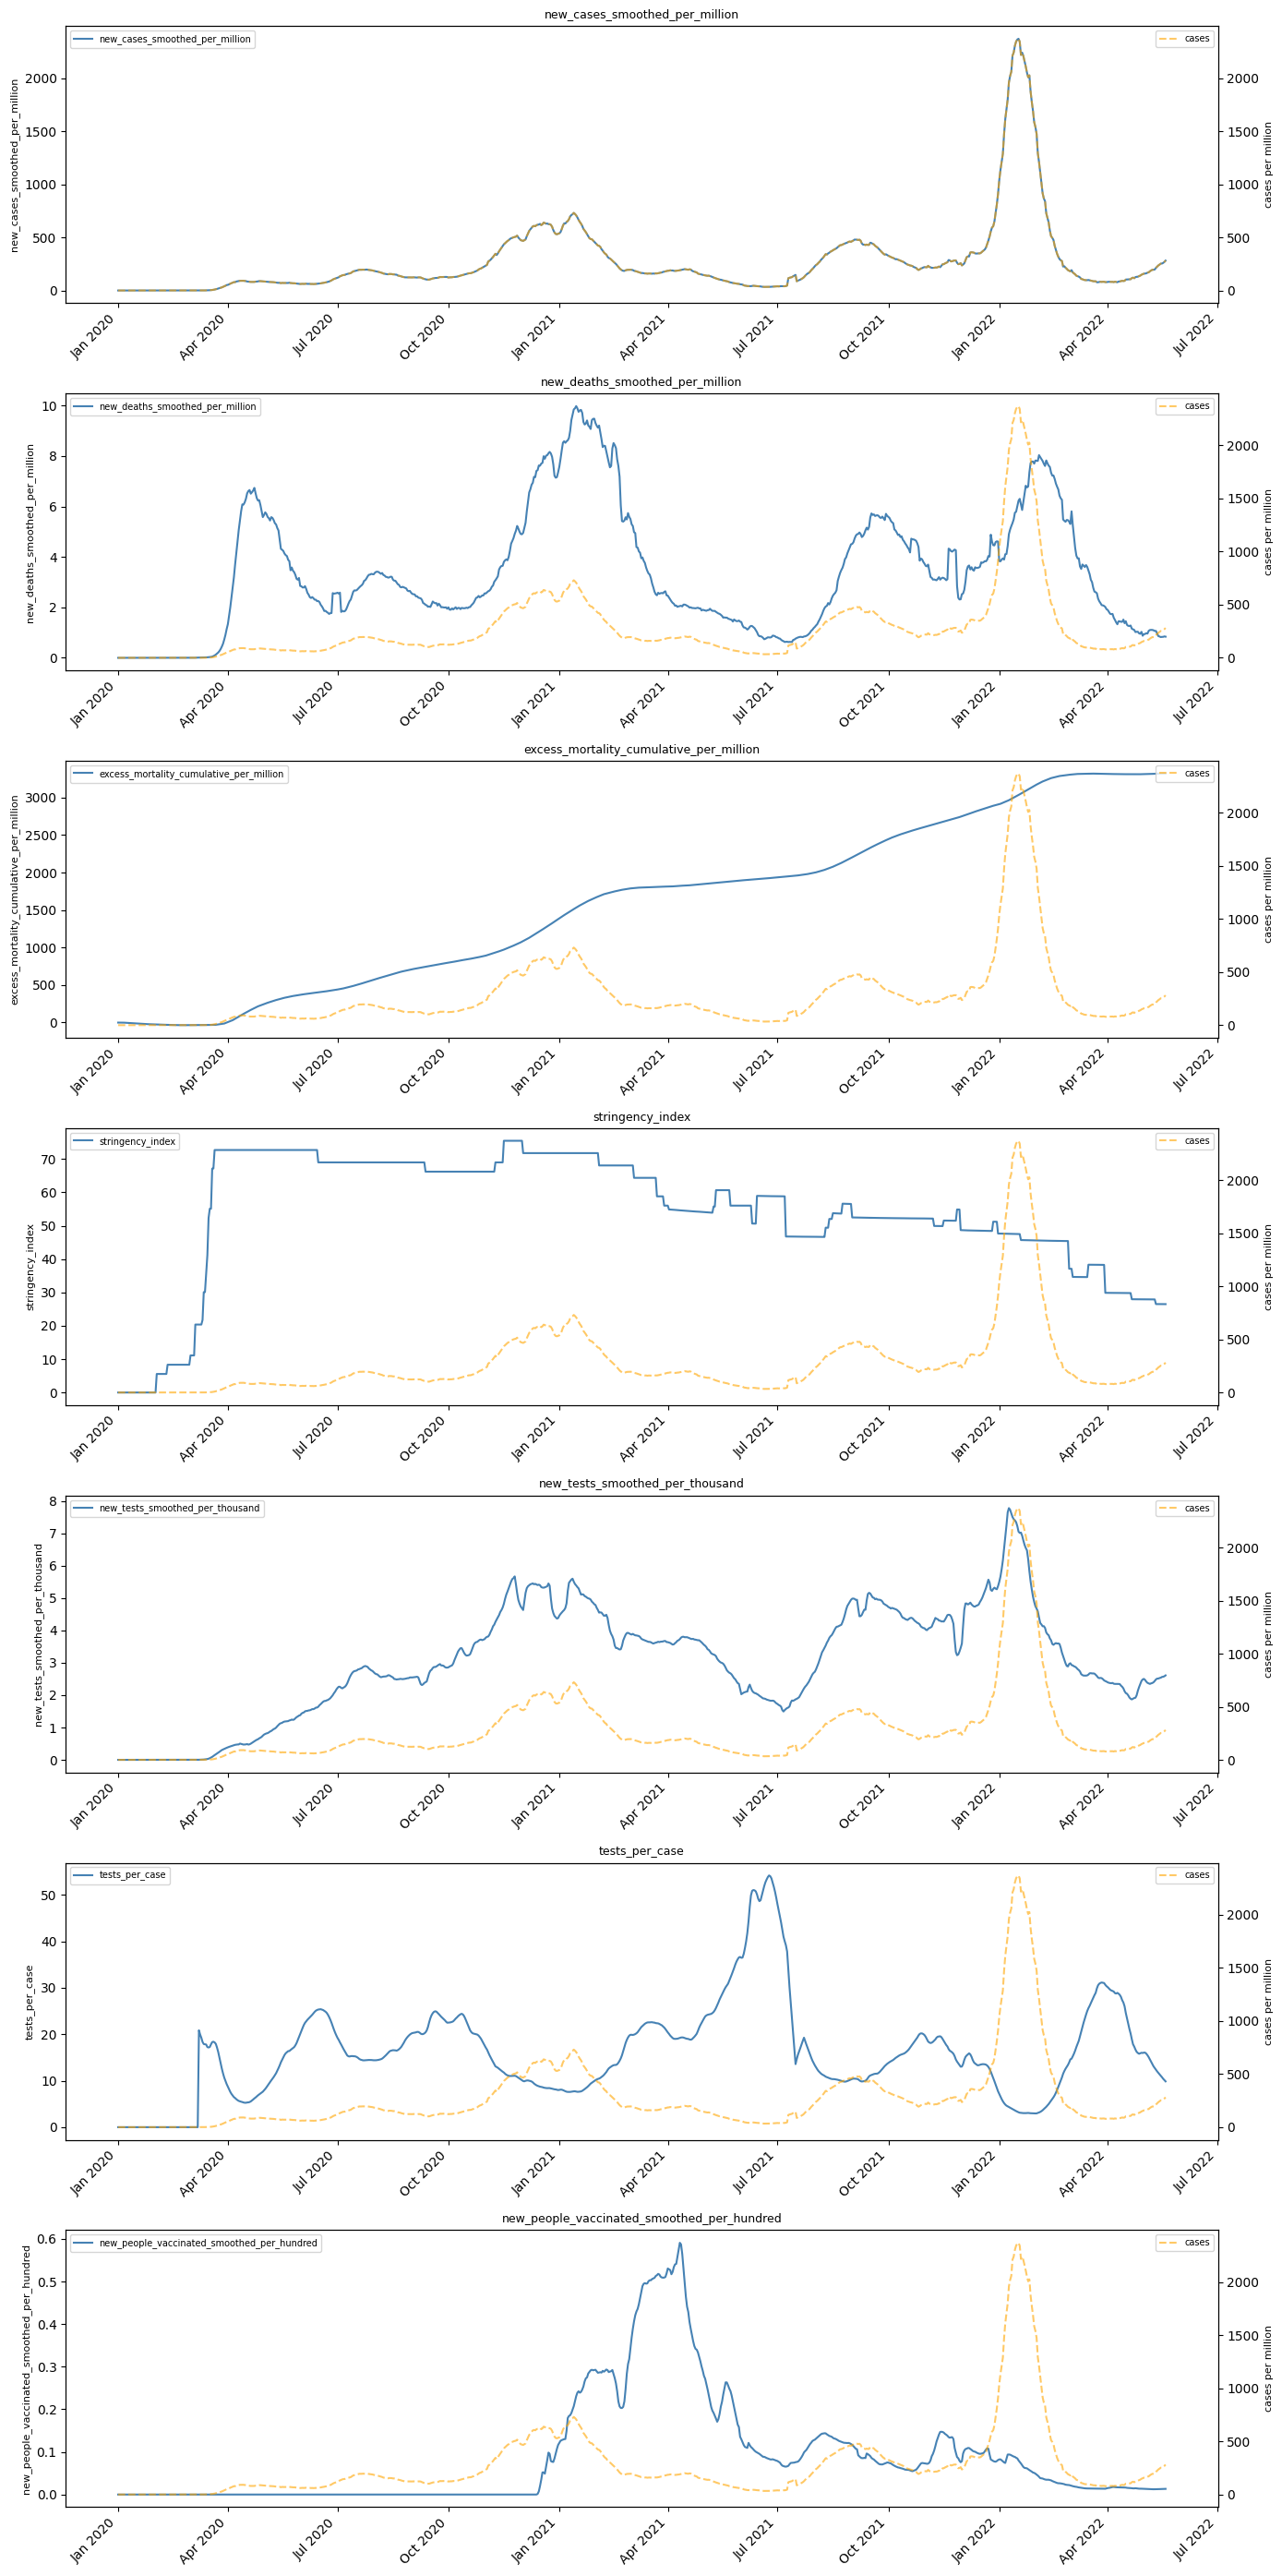

In [133]:
fig, axes = plt.subplots(len(cols_of_interest_time), 1, figsize=(14, 4 * len(cols_of_interest_time)))
subset = df[df['country'] == 'United States']

for i, col in enumerate(cols_of_interest_time):
    ax = axes[i]
    ax2 = ax.twinx()
    
    ax.plot(subset['date'], subset[col], label=col, color='steelblue')
    ax2.plot(subset['date'], subset['new_cases_smoothed_per_million'],
             linestyle='--', alpha=0.6, color='orange', label='cases')
    
    ax.set_ylabel(col, fontsize=8)
    ax2.set_ylabel('cases per million', fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax2.legend(fontsize=7, loc='upper right')
    
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()